# Python Seminar #8：XGBoostによるタイタニック生存者予測

`train_titanic.csv` だけを使って生存者予測モデルをゼロから学習し、
`test_titanic.csv` の `Survived` を予測する。

## レギュレーションへの対応

- 評価指標：生存者（`Survived = 1`）を正例とした **F1スコア**
- 外部データの追加：なし（提供された2つのCSVだけを使用）
- 最終提出モデル：XGBoost 1個（CV中のモデルはハイパーパラメータ調整専用）
- 学習：提供trainデータからゼロから実施。LLMはモデルに組み込まない
- 提出値：最終XGBoostの予測確率を、CVで選んだ閾値で0/1に変換
- シード値：すべて `8`

## 処理の流れ

1. データと欠損・クラス比率の確認
2. 行ごとの特徴量作成とOne-hot encoding
3. seed 8の層化5-fold交差検証で20候補を比較
4. 各foldでearly stoppingを行い、OOF予測でF1閾値を選択
5. 全trainデータでXGBoost 1個を再学習し、testを予測
6. `PassengerId, Survived` の提出用CSVを出力
7. 当日配布される `y_answer` を貼り付けてF1を表示

In [1]:
# ファイル操作・乱数・実行時間の計測に使う標準ライブラリを読み込む。
from pathlib import Path
import os
import random
import sys
import time

# サンドボックス環境でもMatplotlibのキャッシュ警告を出さないため、
# import前に書き込み可能な一時ディレクトリを指定する。
# Matplotlibの設定ファイルを一時ディレクトリへ保存する。
os.environ.setdefault("MPLCONFIGDIR", "/tmp/pysemi8-matplotlib")

# データ処理、可視化、機械学習、XGBoostのライブラリを読み込む。
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

# 課題の規定どおり、乱数に関係する設定をすべて8へ統一する。
RANDOM_STATE = 8
N_SPLITS = 5
N_CANDIDATES = 20
MAX_ESTIMATORS = 2_000
EARLY_STOPPING_ROUNDS = 50
THRESHOLD_GRID = np.round(np.arange(0.20, 0.801, 0.01), 2)

# Python標準ライブラリとNumPyの乱数を固定し、再実行時の結果をそろえる。
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 表示する表とグラフを読みやすい見た目にそろえる。
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# 使用したライブラリのバージョンを出力し、再現可能な実行環境を記録する。
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"seed: {RANDOM_STATE}")

Python: 3.11.15
pandas: 3.0.3
scikit-learn: 1.9.0
XGBoost: 3.2.0
seed: 8


## 1. 用語と前処理が必要な理由

### F1スコア

Accuracy（正解率）だけでは、クラス数に偏りがあると多数派を当てるだけのモデルを高く評価する場合がある。
今回は「生存（1）」について、**適合率（Precision）**と**再現率（Recall）**の調和平均であるF1を使う。

$$
F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}
$$

### アンサンブル学習・ブースティング・XGBoost

- **アンサンブル学習**：複数の弱い学習器を組み合わせ、1個より安定した予測を得る方法
- **ブースティング**：前の木が間違えた部分を、次の木が順番に補う方法
- **XGBoost**：勾配ブースティング決定木に正則化や高速化を加えた手法。今回の最終モデルはXGBoost 1個とする

### One-hot encodingが必要な理由

`Sex` や `Embarked` のような文字列カテゴリを、この実装のXGBoostへそのまま入力することはできない。
また、カテゴリを単純に `0, 1, 2` と置き換えると、存在しない大小関係をモデルが利用する恐れがある。
One-hot encodingではカテゴリごとに0/1列を作るため、その誤った順序を持ち込まずに木を分岐できる。

`handle_unknown="ignore"` を使い、trainのfoldで見なかったカテゴリが検証データやtestに現れてもエラーにしない。

### 欠損値を処理する理由

`Age` や `Cabin` には欠損がある。数値列は各foldの学習部分から求めた中央値、カテゴリ列は `Unknown` で補う。
さらに `AgeMissing` と `HasCabin` を作り、「欠損していたこと」自体の情報も残す。
前処理をfoldの学習部分だけでfitすることで、検証データの情報が学習へ混ざるデータ漏洩を防ぐ。

XGBoostは決定木ベースなので、距離や係数の大きさを使うモデルと違い、標準化は必須ではない。

In [2]:
# 入力CSVの場所と、目的変数・ID列の名前を定義する。
TRAIN_PATH = Path("train_titanic.csv")
TEST_PATH = Path("test_titanic.csv")
TARGET = "Survived"
ID_COLUMN = "PassengerId"

# ファイルが存在しないまま後続の処理を進めないように確認する。
for path in (TRAIN_PATH, TEST_PATH):
    if not path.exists():
        raise FileNotFoundError(f"データファイルが見つかりません: {path.resolve()}")

# trainには正解Survived、testには予測対象だけを読み込む。
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# 配布データと異なるファイルを誤って使っていないか、行数でも確認する。
EXPECTED_TRAIN_ROWS = 712
EXPECTED_TEST_ROWS = 179
if len(train) != EXPECTED_TRAIN_ROWS or len(test) != EXPECTED_TEST_ROWS:
    raise ValueError(
        f"想定行数と一致しません: train={len(train)}, test={len(test)} "
        f"（期待値: {EXPECTED_TRAIN_ROWS}, {EXPECTED_TEST_ROWS}）"
    )

# 列構成、IDの一意性、目的変数が0/1であることを検査する。
if TARGET not in train.columns:
    raise KeyError(f"trainに目的変数 {TARGET} がありません。")
if TARGET in test.columns:
    raise ValueError(f"testに正解列 {TARGET} が含まれています。")
if list(train.drop(columns=TARGET).columns) != list(test.columns):
    raise ValueError("trainの説明変数列とtestの列または列順が一致しません。")
if train[ID_COLUMN].duplicated().any() or test[ID_COLUMN].duplicated().any():
    raise ValueError("PassengerIdに重複があります。")
if set(train[ID_COLUMN]) & set(test[ID_COLUMN]):
    raise ValueError("trainとtestのPassengerIdが重複しています。")
if train[TARGET].isna().any() or not set(train[TARGET].unique()).issubset({0, 1}):
    raise ValueError("Survivedは欠損なしの0/1である必要があります。")

# 学習用の説明変数X、正解y、testのIDを分けて保持する。
X_raw = train.drop(columns=TARGET).copy()
y = train[TARGET].astype(int).copy()
X_test_raw = test.copy()
test_ids = test[ID_COLUMN].astype(int).copy()

# 読み込んだデータのサイズとクラス比率を表示する。
print(f"train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"test : {test.shape[0]} rows × {test.shape[1]} columns")
print(f"positive rate (Survived=1): {y.mean():.2%}")
display(train.head())

train: 712 rows × 12 columns
test : 179 rows × 11 columns
positive rate (Survived=1): 38.34%


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
1,465,0,3,"Maisner, Mr. Simon",male,NaN,0,0,A/S 2816,8.0500,NaN,S
2,199,1,3,"Madigan, Miss. Margaret ""Maggie""",female,NaN,0,0,370370,7.7500,NaN,Q
3,766,1,1,"Hogeboom, Mrs. John C (Anna Andrews)",female,51.0,1,0,13502,77.9583,D11,S
4,422,0,3,"Charters, Mr. David",male,21.0,0,0,A/5. 13032,7.7333,NaN,Q


In [3]:
# 各列の型・欠損数・欠損率・ユニーク数を一覧にする関数。
def data_summary(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    summary = pd.DataFrame(
        {
            "dtype": frame.dtypes.astype(str),
            "missing": frame.isna().sum(),
            "missing_rate": frame.isna().mean(),
            "unique": frame.nunique(dropna=True),
        }
    )
    summary.index.name = f"{name} column"
    return summary


# 生存(1)と死亡(0)の件数・割合を集計する。
class_summary = (
    y.value_counts()
    .sort_index()
    .rename_axis(TARGET)
    .to_frame("count")
    .assign(rate=lambda table: table["count"] / len(y))
)

# 集計表をノートブック上に表示する。
display(class_summary.style.format({"rate": "{:.2%}"}))
display(data_summary(train, "train").style.format({"missing_rate": "{:.2%}"}))
display(data_summary(test, "test").style.format({"missing_rate": "{:.2%}"}))

,count,rate
Survived,,
0,439,61.66%
1,273,38.34%


,dtype,missing,missing_rate,unique
train column,,,,
PassengerId,int64,0,0.00%,712
Survived,int64,0,0.00%,2
Pclass,int64,0,0.00%,3
Name,str,0,0.00%,712
Sex,str,0,0.00%,2
Age,float64,146,20.51%,82
SibSp,int64,0,0.00%,7
Parch,int64,0,0.00%,7
Ticket,str,0,0.00%,565


,dtype,missing,missing_rate,unique
test column,,,,
PassengerId,int64,0,0.00%,179
Pclass,int64,0,0.00%,3
Name,str,0,0.00%,179
Sex,str,0,0.00%,2
Age,float64,31,17.32%,63
SibSp,int64,0,0.00%,6
Parch,int64,0,0.00%,6
Ticket,str,0,0.00%,168
Fare,float64,0,0.00%,106


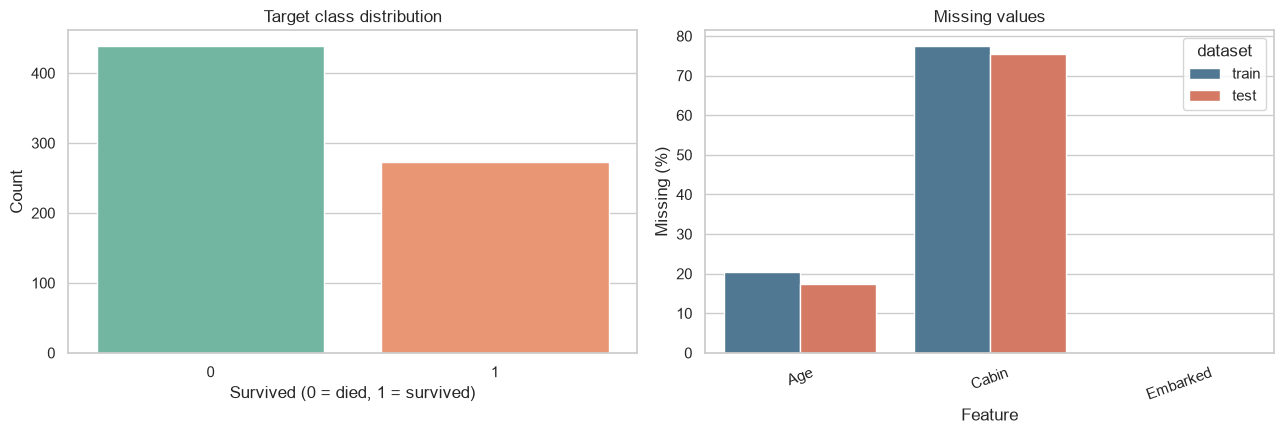

In [4]:
# train/testごとに、各列の欠損率をパーセントで計算する。
train_missing = train.isna().mean().mul(100).rename("train")
test_missing = test.isna().mean().mul(100).rename("test")
# 2つのデータセットを縦長の表へ整形し、Seabornで描ける形にする。
missing_plot = (
    pd.concat([train_missing, test_missing], axis=1)
    .fillna(0)
    .query("train > 0 or test > 0")
    .rename_axis("feature")
    .reset_index()
    .melt(id_vars="feature", var_name="dataset", value_name="missing_percent")
)

# 左にクラス比率、右に欠損率を並べて確認する。
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 目的変数の偏りを棒グラフで確認する。
sns.countplot(x=y, hue=y, palette="Set2", legend=False, ax=axes[0])
axes[0].set(
    title="Target class distribution",
    xlabel="Survived (0 = died, 1 = survived)",
    ylabel="Count",
)

# train/testで欠損率が大きく違わないかを確認する。
sns.barplot(
    data=missing_plot,
    x="feature",
    y="missing_percent",
    hue="dataset",
    palette=["#457B9D", "#E76F51"],
    ax=axes[1],
)
axes[1].set(title="Missing values", xlabel="Feature", ylabel="Missing (%)")
axes[1].tick_params(axis="x", rotation=20)

# グラフ同士の重なりを防いで表示する。
plt.tight_layout()
plt.show()

## 2. 特徴量エンジニアリング

`Name`、`Ticket`、`Cabin` の生値は種類が多く、そのままOne-hot化するとほぼ個人専用の列が増えて過学習しやすい。
そこで、外部データや正解ラベルを使わず、各行の情報だけから次の安定した特徴へ要約する。

- `Name` → 敬称 `Title`（Mr / Miss / Mrs / Master / Rare）
- `SibSp`, `Parch` → `FamilySize`, `IsAlone`
- `Cabin` → 先頭文字の `CabinDeck`, `HasCabin`
- `Ticket` → 数字と記号を除いた `TicketPrefix`
- `Age` → `AgeMissing`
- `Fare` → `FarePerPerson = Fare / FamilySize`

`PassengerId` は提出時の突き合わせに必要だが、一意な識別子なので学習には使わない。

In [5]:
# One-hot encodingするカテゴリ列と、数値のまま扱う列を明示する。
CATEGORICAL_COLUMNS = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "CabinDeck",
    "TicketPrefix",
]
NUMERIC_COLUMNS = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "AgeMissing",
    "HasCabin",
    "FarePerPerson",
]


# 生の列を、過学習しにくく意味のある特徴量へ変換する関数。
def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    """提供CSVの各行だけから、学習に使う特徴量を作る。"""
    # この関数で使う元列が揃っているかを確認する。
    required = {
        "Pclass", "Name", "Sex", "Age", "SibSp", "Parch",
        "Ticket", "Fare", "Cabin", "Embarked",
    }
    missing_columns = required - set(frame.columns)
    if missing_columns:
        raise KeyError(f"特徴量作成に必要な列がありません: {sorted(missing_columns)}")

    # 元のDataFrameを直接書き換えず、新しい特徴量用DataFrameを用意する。
    features = pd.DataFrame(index=frame.index)

    # Pclassは数値の大小ではなく客室等級のカテゴリとして文字列化する。
    pclass = pd.to_numeric(frame["Pclass"], errors="coerce").astype("Int64")
    features["Pclass"] = pclass.astype("string").fillna("Unknown")
    features["Sex"] = frame["Sex"].astype("string").fillna("Unknown")
    features["Embarked"] = frame["Embarked"].astype("string").fillna("Unknown")

    # 数値列を安全に数値型へ変換する。変換できない値は欠損値になる。
    age = pd.to_numeric(frame["Age"], errors="coerce")
    sibsp = pd.to_numeric(frame["SibSp"], errors="coerce")
    parch = pd.to_numeric(frame["Parch"], errors="coerce")
    fare = pd.to_numeric(frame["Fare"], errors="coerce")

    features["Age"] = age
    features["SibSp"] = sibsp
    features["Parch"] = parch
    features["Fare"] = fare

    # 同乗している家族数から、単独乗船かどうかと1人あたり運賃を作る。
    family_size = sibsp + parch + 1
    features["FamilySize"] = family_size
    features["IsAlone"] = family_size.eq(1).astype("int8")
    features["AgeMissing"] = age.isna().astype("int8")
    features["FarePerPerson"] = fare / family_size

    # 氏名から敬称を取り出し、少数の敬称はRareへまとめる。
    title = (
        frame["Name"]
        .astype("string")
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
        .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    )
    common_titles = {"Mr", "Miss", "Mrs", "Master"}
    features["Title"] = title.where(title.isin(common_titles), "Rare").fillna("Rare")

    # Cabinの先頭文字（デッキ）と、Cabin情報の有無を特徴量にする。
    cabin = frame["Cabin"].astype("string").fillna("").str.strip()
    features["CabinDeck"] = cabin.str.slice(0, 1).replace("", "Unknown").fillna("Unknown")
    features["HasCabin"] = cabin.ne("").astype("int8")

    # Ticket番号から数字・記号を除き、券種の接頭辞だけを使う。
    ticket_prefix = (
        frame["Ticket"]
        .astype("string")
        .fillna("")
        .str.upper()
        .str.replace(r"\d+", "", regex=True)
        .str.replace(r"[^A-Z]+", "", regex=True)
        .replace("", "NONE")
    )
    features["TicketPrefix"] = ticket_prefix

    # 指定した順序で列を返し、train/testの特徴量順を統一する。
    return features[CATEGORICAL_COLUMNS + NUMERIC_COLUMNS]


# train/testへまったく同じ特徴量作成処理を適用する。
X = make_features(X_raw)
X_test = make_features(X_test_raw)

if list(X.columns) != list(X_test.columns):
    raise ValueError("trainとtestで作成された特徴量が一致しません。")

# 作成後の特徴量について、種類数と欠損の状態を比較する。
feature_overview = pd.DataFrame(
    {
        "dtype": X.dtypes.astype(str),
        "train_unique": X.nunique(dropna=True),
        "test_unique": X_test.nunique(dropna=True),
        "train_missing": X.isna().sum(),
        "test_missing": X_test.isna().sum(),
    }
)
display(X.head())
display(feature_overview)

,Pclass,Sex,Embarked,Title,CabinDeck,TicketPrefix,Age,SibSp,Parch,Fare,FamilySize,IsAlone,AgeMissing,HasCabin,FarePerPerson
0,3,female,Q,Miss,Unknown,NONE,NaN,0,0,7.6292,1,1,1,0,7.62920
1,3,male,S,Mr,Unknown,AS,NaN,0,0,8.0500,1,1,1,0,8.05000
2,3,female,Q,Miss,Unknown,NONE,NaN,0,0,7.7500,1,1,1,0,7.75000
3,1,female,S,Mrs,D,NONE,51.0,1,0,77.9583,2,0,0,1,38.97915
4,3,male,Q,Mr,Unknown,A,21.0,0,0,7.7333,1,1,0,0,7.73330


,dtype,train_unique,test_unique,train_missing,test_missing
Pclass,string,3,3,0,0
Sex,string,2,2,0,0
Embarked,string,4,3,0,0
Title,string,5,5,0,0
CabinDeck,string,9,8,0,0
TicketPrefix,string,28,12,0,0
Age,float64,82,63,146,31
SibSp,int64,7,6,0,0
Parch,int64,7,6,0,0
Fare,float64,223,106,0,0


## 3. 前処理パイプライン

- 数値列：学習foldの中央値で補完
- カテゴリ列：`Unknown`で補完してOne-hot encoding
- testや検証foldで初めて現れるカテゴリ：`handle_unknown="ignore"`で全0として扱う

前処理器は交差検証のfoldごとに作り直し、**学習foldだけで `fit`** する。
最終モデルでは、ハイパーパラメータ決定後に全trainデータで前処理器をfitし直す。

In [6]:
# foldごと・最終学習ごとに新しい前処理器を作る関数。
def build_preprocessor() -> ColumnTransformer:
    # 数値列の欠損は、その学習データ内の中央値で補完する。
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )
    # カテゴリ列の欠損はUnknownにし、0/1列へOne-hot encodingする。
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                    dtype=np.float32,
                ),
            ),
        ]
    )

    # カテゴリ列と数値列へ別々の処理を適用して結合する。
    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipeline, CATEGORICAL_COLUMNS),
            ("numeric", numeric_pipeline, NUMERIC_COLUMNS),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=False,
    )


# 全trainでの変換後の列数を確認するためだけのプレビュー。学習には使わない。
preview_preprocessor = build_preprocessor()
X_preview = preview_preprocessor.fit_transform(X)
print(f"元の特徴量数: {X.shape[1]}")
print(f"One-hot encoding後の特徴量数: {X_preview.shape[1]}")

元の特徴量数: 15
One-hot encoding後の特徴量数: 60


## 4. 層化5-fold CVとハイパーパラメータ探索

単一の80:20分割だけで最良条件を選ぶと、約142件の検証データへの偶然適合が起きやすい。
そこで `Survived` の比率を保った5-fold交差検証を使い、全712件について一度ずつOOF（out-of-fold）予測を作る。

各foldでは最大2,000本の木を指定するが、検証foldのloglossが50回改善しなければearly stoppingする。
early stoppingには連続的で安定したloglossを使い、モデル・閾値の最終選択はレギュレーションどおりF1で行う。

20候補すべてについて、共通の閾値0.20〜0.80を0.01刻みで評価する。
平均fold F1が最大の候補を選び、同点時はfold間標準偏差が小さいもの、閾値が0.5に近いもの、木が浅いものを優先する。

In [7]:
# sklearn/XGBoostで扱いやすいNumPy配列へ目的変数を変換する。
y_array = y.to_numpy(dtype=int)
# 各foldで生存/死亡の割合をほぼ保つ5分割を、seed 8で固定する。
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# foldごとの変換済みデータとインデックスを保存する入れ物。
fold_data = []
fold_assignment = np.full(len(X), -1, dtype=int)

# 5つの分割を順に作り、検証用のOOF予測に使えるようにする。
for fold, (train_index, valid_index) in enumerate(cv.split(X, y_array), start=1):
    # 各学習・検証foldに0と1の両方が含まれることを確認する。
    if set(y_array[train_index]) != {0, 1} or set(y_array[valid_index]) != {0, 1}:
        raise RuntimeError(f"fold {fold} の学習または検証データに両クラスが含まれていません。")
    # 重要：前処理器は学習foldだけでfitし、検証foldはtransformだけにする。
    fold_preprocessor = build_preprocessor()
    X_fold_train = fold_preprocessor.fit_transform(X.iloc[train_index])
    X_fold_valid = fold_preprocessor.transform(X.iloc[valid_index])

    # どの行がどの検証foldだったかを記録する。
    fold_assignment[valid_index] = fold
    fold_data.append(
        {
            "fold": fold,
            "train_index": train_index,
            "valid_index": valid_index,
            "X_train": X_fold_train,
            "X_valid": X_fold_valid,
            "y_train": y_array[train_index],
            "y_valid": y_array[valid_index],
            "encoded_features": X_fold_train.shape[1],
        }
    )

# 全行がちょうど一度は検証データになったかを検査する。
if (fold_assignment < 0).any() or not np.all(np.bincount(fold_assignment)[1:] > 0):
    raise RuntimeError("OOF foldの割り当てに失敗しました。")

# foldの行数・クラス比率・変換後特徴量数を表にする。
fold_summary = pd.DataFrame(
    {
        "fold": [item["fold"] for item in fold_data],
        "train_rows": [len(item["train_index"]) for item in fold_data],
        "valid_rows": [len(item["valid_index"]) for item in fold_data],
        "train_positive_rate": [item["y_train"].mean() for item in fold_data],
        "valid_positive_rate": [item["y_valid"].mean() for item in fold_data],
        "encoded_features": [item["encoded_features"] for item in fold_data],
    }
)
display(
    fold_summary.style.format(
        {"train_positive_rate": "{:.2%}", "valid_positive_rate": "{:.2%}"}
    )
)

,fold,train_rows,valid_rows,train_positive_rate,valid_positive_rate,encoded_features
0,1,569,143,38.31%,38.46%,59
1,2,569,143,38.31%,38.46%,59
2,3,570,142,38.42%,38.03%,57
3,4,570,142,38.42%,38.03%,55
4,5,570,142,38.25%,38.73%,60


In [8]:
# 生存者が少ないクラス不均衡を考慮する重み候補を計算する。
negative_positive_ratio = (y_array == 0).sum() / (y_array == 1).sum()

# 過学習を抑えつつ試すXGBoostハイパーパラメータの候補範囲。
parameter_space = {
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.02, 0.03, 0.05, 0.075, 0.10],
    "min_child_weight": [1, 2, 4, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0.0, 0.05, 0.10, 0.25, 0.50],
    "reg_alpha": [0.0, 0.01, 0.10, 0.50, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
    "scale_pos_weight": [1.0, 1.2, 1.4, negative_positive_ratio],
}

# 全組合せを試す代わりに、seed 8で20候補をランダムに選ぶ。
sampled_parameters = list(
    ParameterSampler(
        parameter_space,
        n_iter=N_CANDIDATES,
        random_state=RANDOM_STATE,
    )
)

# 実際に試す候補とクラス比率を確認する。
print(f"探索候補数: {len(sampled_parameters)}")
print(f"負例数 / 正例数: {negative_positive_ratio:.4f}")
display(pd.DataFrame(sampled_parameters).head())

探索候補数: 20
負例数 / 正例数: 1.6081


,subsample,scale_pos_weight,reg_lambda,reg_alpha,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree
0,1.0,1.0,1.0,0.10,4,5,0.050,0.25,1.0
1,0.7,1.2,2.0,0.10,8,5,0.020,0.10,1.0
2,0.8,1.0,10.0,0.00,4,3,0.075,0.50,0.7
3,0.8,1.2,1.0,0.50,6,2,0.030,0.10,0.8
4,0.9,1.4,2.0,0.01,8,4,0.020,0.00,0.9


In [9]:
# OOF確率を0/1へ変える閾値ごとに、fold平均F1を計算する関数。
def evaluate_threshold_grid(oof_probability: np.ndarray) -> pd.DataFrame:
    # 各閾値の結果を1行ずつ蓄積する。
    rows = []
    # 0.20〜0.80を0.01刻みで試す。
    for threshold in THRESHOLD_GRID:
        fold_scores = []
        # 同じ閾値を全foldへ適用し、F1の平均とばらつきを出す。
        for fold in range(1, N_SPLITS + 1):
            mask = fold_assignment == fold
            predictions = (oof_probability[mask] >= threshold).astype(int)
            fold_scores.append(
                f1_score(y_array[mask], predictions, pos_label=1, zero_division=0)
            )

        rows.append(
            {
                "threshold": float(threshold),
                "cv_f1_mean": float(np.mean(fold_scores)),
                "cv_f1_std": float(np.std(fold_scores, ddof=0)),
                "threshold_distance": float(abs(threshold - 0.5)),
            }
        )

    # F1最大、ばらつき最小、0.5に近い閾値の順に並べる。
    return pd.DataFrame(rows).sort_values(
        ["cv_f1_mean", "cv_f1_std", "threshold_distance", "threshold"],
        ascending=[False, True, True, True],
        ignore_index=True,
    )


# 各ハイパーパラメータ候補の結果と、再利用するOOF予測を保存する。
search_rows = []
candidate_artifacts = {}
search_started = time.perf_counter()

# 20候補について、5-fold学習とF1閾値探索を順に行う。
for candidate_number, parameters in enumerate(sampled_parameters, start=1):
    # 全train行のOOF生存確率を入れる配列と、foldごとの最適木数を用意する。
    oof_probability = np.full(len(X), np.nan, dtype=float)
    best_rounds = []

    # この候補を各foldの学習データで学習し、未学習の検証foldを予測する。
    for item in fold_data:
        # 最大2,000本まで木を作り、loglossが改善しなければearly stoppingする。
        fold_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_estimators=MAX_ESTIMATORS,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            **parameters,
        )
        # 変換済みの学習foldでfitし、検証foldをearly stopping用に渡す。
        fold_model.fit(
            item["X_train"],
            item["y_train"],
            eval_set=[(item["X_valid"], item["y_valid"])],
            verbose=False,
        )

        # 検証foldの生存確率を回収し、元の行位置へ格納する。
        valid_probability = fold_model.predict_proba(item["X_valid"])[:, 1]
        oof_probability[item["valid_index"]] = valid_probability
        best_rounds.append(int(fold_model.best_iteration) + 1)

    # すべてのtrain行についてOOF確率が得られたかを確認する。
    if np.isnan(oof_probability).any():
        raise RuntimeError(f"candidate {candidate_number} のOOF予測に欠損があります。")

    # この候補に最も合う、全fold共通のF1閾値を選ぶ。
    threshold_table = evaluate_threshold_grid(oof_probability)
    best_threshold_row = threshold_table.iloc[0]
    best_threshold = float(best_threshold_row["threshold"])
    oof_prediction = (oof_probability >= best_threshold).astype(int)

    # 候補のパラメータ、F1、閾値、early stopping後の木数を記録する。
    row = {
        "candidate": candidate_number,
        **parameters,
        "best_threshold": best_threshold,
        "cv_f1_mean": float(best_threshold_row["cv_f1_mean"]),
        "cv_f1_std": float(best_threshold_row["cv_f1_std"]),
        "oof_f1": f1_score(y_array, oof_prediction, pos_label=1, zero_division=0),
        "oof_average_precision": average_precision_score(y_array, oof_probability),
        "median_best_rounds": int(np.median(best_rounds)),
        "threshold_distance": abs(best_threshold - 0.5),
    }
    search_rows.append(row)
    candidate_artifacts[candidate_number] = {
        "parameters": parameters,
        "oof_probability": oof_probability,
        "best_rounds": best_rounds,
        "threshold_table": threshold_table,
    }

    # 長い探索中も途中経過を表示する。
    if candidate_number == 1 or candidate_number % 5 == 0:
        print(
            f"candidate {candidate_number:>2}/{N_CANDIDATES}: "
            f"mean F1={row['cv_f1_mean']:.4f}, "
            f"threshold={best_threshold:.2f}, "
            f"median rounds={row['median_best_rounds']}"
        )

# 全候補の結果を比較して、最終的に使う1候補を決める。
elapsed_seconds = time.perf_counter() - search_started
search_results = pd.DataFrame(search_rows).sort_values(
    ["cv_f1_mean", "cv_f1_std", "threshold_distance", "max_depth", "candidate"],
    ascending=[False, True, True, True, True],
    ignore_index=True,
)

# 並べ替え後の先頭行が、fold平均F1に基づく最良候補。
selected_row = search_results.iloc[0]
selected_candidate = int(selected_row["candidate"])
selected_artifact = candidate_artifacts[selected_candidate]
selected_parameters = selected_artifact["parameters"]
selected_threshold = float(selected_row["best_threshold"])

print(f"\n探索時間: {elapsed_seconds:.1f}秒")
print(f"選択candidate: {selected_candidate}")
display(search_results.head(10).style.format(precision=4))

candidate  1/20: mean F1=0.8037, threshold=0.45, median rounds=111


candidate  5/20: mean F1=0.8076, threshold=0.48, median rounds=410


candidate 10/20: mean F1=0.7898, threshold=0.30, median rounds=627


candidate 15/20: mean F1=0.7874, threshold=0.42, median rounds=476


candidate 20/20: mean F1=0.8163, threshold=0.51, median rounds=124

探索時間: 41.9秒
選択candidate: 20


,candidate,subsample,scale_pos_weight,reg_lambda,reg_alpha,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,best_threshold,cv_f1_mean,cv_f1_std,oof_f1,oof_average_precision,median_best_rounds,threshold_distance
0,20,0.8000,1.4000,1.0000,0.1000,2,3,0.1000,0.2500,0.7000,0.5100,0.8163,0.0542,0.8160,0.8630,124,0.0100
1,12,1.0000,1.4000,2.0000,0.0100,1,3,0.0500,0.1000,0.7000,0.4700,0.8096,0.0593,0.8084,0.8554,102,0.0300
2,8,0.7000,1.4000,5.0000,0.0100,2,5,0.0300,0.2500,0.8000,0.4600,0.8094,0.0519,0.8087,0.8601,288,0.0400
3,7,1.0000,1.0000,2.0000,0.5000,6,5,0.0300,0.1000,0.8000,0.4300,0.8086,0.0551,0.8073,0.8517,241,0.0700
4,18,0.8000,1.6081,2.0000,0.1000,2,4,0.0500,0.0000,0.8000,0.5000,0.8079,0.0524,0.8072,0.8603,136,0.0000
5,5,0.9000,1.4000,2.0000,0.0100,8,4,0.0200,0.0000,0.9000,0.4800,0.8076,0.0517,0.8065,0.8582,410,0.0200
6,19,0.7000,1.4000,10.0000,1.0000,1,4,0.1000,0.2500,0.8000,0.4800,0.8057,0.0603,0.8043,0.8631,130,0.0200
7,17,0.9000,1.2000,5.0000,1.0000,6,4,0.0200,0.1000,0.8000,0.4500,0.8042,0.0586,0.8029,0.8581,555,0.0500
8,1,1.0000,1.0000,1.0000,0.1000,4,5,0.0500,0.2500,1.0000,0.4500,0.8037,0.0557,0.8030,0.8538,111,0.0500
9,3,0.8000,1.0000,10.0000,0.0000,4,3,0.0750,0.5000,0.7000,0.3500,0.8003,0.0516,0.7993,0.8572,249,0.1500


## 5. OOFでの汎化性能

OOF予測は各行について、その行を学習に使っていないモデルから得た予測である。
train全体へfitしたモデル自身のスコアより、未知データに対する性能の目安として適切である。

ただし、このF1はearly stopping、ハイパーパラメータ、閾値の選択にも同じ検証foldを使っているため、完全に未知なtestの最終F1を保証する値ではない。
fold平均と標準偏差を併記し、1回の分割だけの最高値を過信しない。

選択されたハイパーパラメータ


,value
subsample,0.80
scale_pos_weight,1.40
reg_lambda,1.00
reg_alpha,0.10
min_child_weight,2.00
max_depth,3.00
learning_rate,0.10
gamma,0.25
colsample_bytree,0.70


,value
OOF F1,0.8160
OOF Precision,0.8116
OOF Recall,0.8205
OOF Average precision,0.8630
Selected threshold,0.5100
Mean fold F1,0.8163
Std fold F1,0.0542


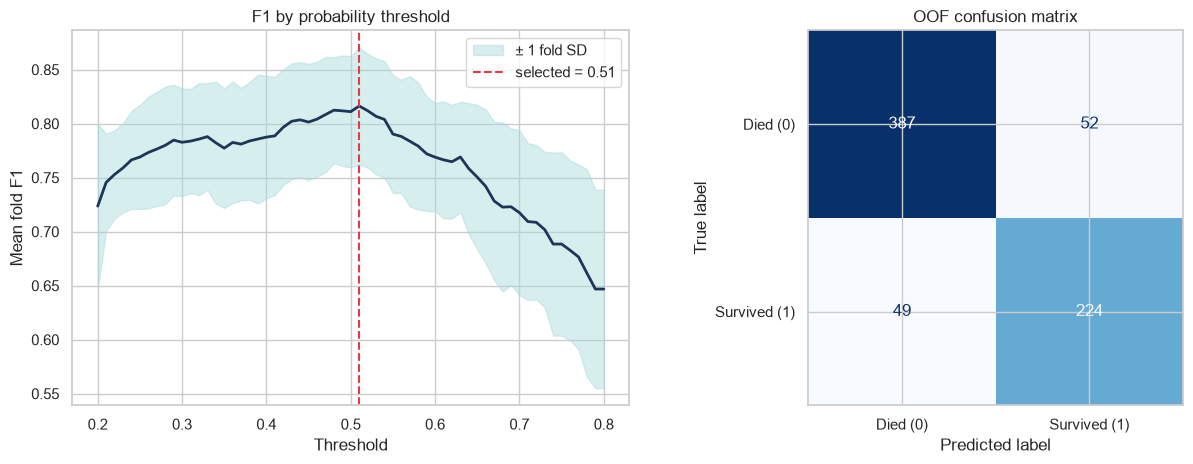

In [10]:
# 選択候補のOOF確率を、選択閾値で0/1の予測へ変換する。
selected_oof_probability = selected_artifact["oof_probability"]
selected_oof_prediction = (selected_oof_probability >= selected_threshold).astype(int)
selected_threshold_table = selected_artifact["threshold_table"].sort_values("threshold")

# F1だけでなくPrecision、Recall、確率の順位性能もまとめる。
oof_metrics = pd.DataFrame(
    {
        "value": [
            f1_score(y_array, selected_oof_prediction, pos_label=1, zero_division=0),
            precision_score(y_array, selected_oof_prediction, pos_label=1, zero_division=0),
            recall_score(y_array, selected_oof_prediction, pos_label=1, zero_division=0),
            average_precision_score(y_array, selected_oof_probability),
            selected_threshold,
            selected_row["cv_f1_mean"],
            selected_row["cv_f1_std"],
        ]
    },
    index=[
        "OOF F1",
        "OOF Precision",
        "OOF Recall",
        "OOF Average precision",
        "Selected threshold",
        "Mean fold F1",
        "Std fold F1",
    ],
)

# 選ばれたパラメータとOOF評価を確認する。
print("選択されたハイパーパラメータ")
display(pd.Series(selected_parameters, name="value").to_frame())
display(oof_metrics.style.format("{:.4f}"))

# 左に閾値とF1の関係、右にOOF混同行列を描く。
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# 閾値を変えたときの平均fold F1を線で示す。
axes[0].plot(
    selected_threshold_table["threshold"],
    selected_threshold_table["cv_f1_mean"],
    color="#1D3557",
    linewidth=2,
)
axes[0].fill_between(
    selected_threshold_table["threshold"],
    selected_threshold_table["cv_f1_mean"] - selected_threshold_table["cv_f1_std"],
    selected_threshold_table["cv_f1_mean"] + selected_threshold_table["cv_f1_std"],
    color="#A8DADC",
    alpha=0.45,
    label="± 1 fold SD",
)
axes[0].axvline(
    selected_threshold,
    color="#E63946",
    linestyle="--",
    label=f"selected = {selected_threshold:.2f}",
)
axes[0].set(title="F1 by probability threshold", xlabel="Threshold", ylabel="Mean fold F1")
axes[0].legend()

# OOF予測の死亡/生存の当たり外れを2×2表で確認する。
oof_cm = confusion_matrix(y_array, selected_oof_prediction, labels=[0, 1])
ConfusionMatrixDisplay(
    confusion_matrix=oof_cm,
    display_labels=["Died (0)", "Survived (1)"],
).plot(cmap="Blues", values_format="d", colorbar=False, ax=axes[1])
axes[1].set_title("OOF confusion matrix")

plt.tight_layout()
plt.show()

## 6. 全trainデータで最終モデルを1個だけ学習

選択candidateの各foldで得た `best_iteration + 1` の中央値を、最終モデルの木の本数とする。
これにより、全trainを使う最終学習で検証データを別に残さなくても、early stoppingで得た適切な複雑さを引き継げる。

ハイパーパラメータ決定後に、前処理器を全trainだけでfitし、testはtransformのみ行う。
最終的に提出する学習済みモデルは、この `final_model` 1個である。

In [11]:
# CVでearly stoppingされた木数の中央値を、最終モデルの木数に使う。
selected_best_rounds = selected_artifact["best_rounds"]
final_n_estimators = max(1, int(np.median(selected_best_rounds)))

# 最終段階では全trainで前処理をfitし、testはtransformだけにする。
final_preprocessor = build_preprocessor()
X_full_encoded = final_preprocessor.fit_transform(X)
X_test_encoded = final_preprocessor.transform(X_test)

# 選択済みのパラメータで、提出用のXGBoost 1個を学習する。
final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=final_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    **selected_parameters,
)
# 最終モデルは検証データを残さず、全trainデータを使ってfitする。
final_model.fit(X_full_encoded, y_array, verbose=False)

# testの生存確率を予測し、CVで選んだ閾値で0/1に変換する。
test_probability = final_model.predict_proba(X_test_encoded)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

# 最終学習に使った木数と変換後のデータ形状を表示する。
print(f"fold別best rounds: {selected_best_rounds}")
print(f"最終モデルの木の本数: {final_n_estimators}")
print(f"最終閾値: {selected_threshold:.2f}")
print(f"train encoded shape: {X_full_encoded.shape}")
print(f"test encoded shape : {X_test_encoded.shape}")

fold別best rounds: [55, 13, 131, 124, 125]
最終モデルの木の本数: 124
最終閾値: 0.51
train encoded shape: (712, 60)
test encoded shape : (179, 60)


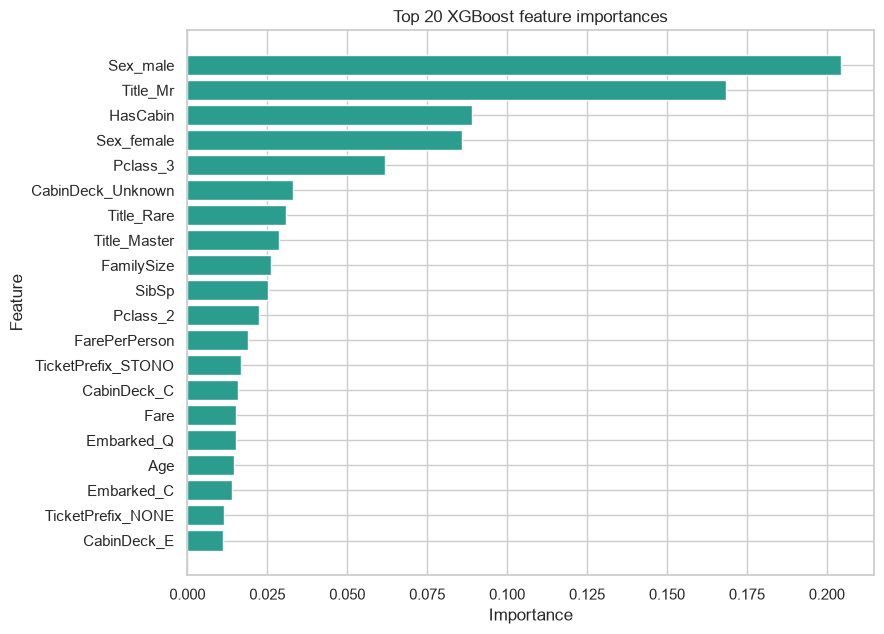

,feature,importance
0,Sex_male,0.2045
1,Title_Mr,0.1684
2,HasCabin,0.0890
3,Sex_female,0.0858
4,Pclass_3,0.0619
5,CabinDeck_Unknown,0.0330
6,Title_Rare,0.0307
7,Title_Master,0.0287
8,FamilySize,0.0261
9,SibSp,0.0251


In [12]:
# One-hot encoding後の列名を取得し、重要度と対応付ける。
encoded_feature_names = final_preprocessor.get_feature_names_out()
# 列名とXGBoostが返した重要度の数が一致するか確認する。
if len(encoded_feature_names) != len(final_model.feature_importances_):
    raise RuntimeError("特徴量名とfeature importanceの長さが一致しません。")

# 重要度を降順の表にし、どの特徴量が効いたか確認する。
feature_importance = (
    pd.DataFrame(
        {
            "feature": encoded_feature_names,
            "importance": final_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False, ignore_index=True)
)

# 上位20特徴量だけを横棒グラフで見やすく表示する。
top_importance = feature_importance.head(20).sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top_importance["feature"], top_importance["importance"], color="#2A9D8F")
ax.set(title="Top 20 XGBoost feature importances", xlabel="Importance", ylabel="Feature")
plt.tight_layout()
plt.show()

# 数値も確認できるよう、重要度表を表示する。
display(feature_importance.head(20).style.format({"importance": "{:.4f}"}))

## 7. test予測と提出用CSV

testの各行について、最終XGBoostが出した生存確率を選択閾値で0/1へ変換する。
手動ルールによる上書きや外部の正解情報は使わない。

採点コードと資料の形式に合わせ、公開変数 `y_pred` とCSVは次の2列だけにする。

1. `PassengerId`
2. `Survived`

In [13]:
# 提出用CSVの保存先を決める。
PREDICTION_PATH = Path("pysemi8_xgboost_predictions.csv")

# 資料・採点コードが要求するPassengerId, Survivedの2列だけを作る。
y_pred = pd.DataFrame(
    {
        ID_COLUMN: test_ids.to_numpy(dtype=int),
        TARGET: test_prediction.astype(int),
    }
)

# 行数、列順、ID順、二値ラベルを確認して提出ミスを防ぐ。
if list(y_pred.columns) != [ID_COLUMN, TARGET]:
    raise RuntimeError("提出列または列順が不正です。")
if len(y_pred) != len(test):
    raise RuntimeError("提出行数がtestと一致しません。")
if y_pred[ID_COLUMN].duplicated().any():
    raise RuntimeError("提出PassengerIdに重複があります。")
if not np.array_equal(y_pred[ID_COLUMN].to_numpy(), test_ids.to_numpy()):
    raise RuntimeError("提出PassengerIdまたは行順がtestと一致しません。")
if y_pred.isna().any().any() or not set(y_pred[TARGET].unique()).issubset({0, 1}):
    raise RuntimeError("提出予測は欠損なしの0/1である必要があります。")

# index列を追加せずにCSV保存し、読み戻して内容が変わらないか検査する。
y_pred.to_csv(PREDICTION_PATH, index=False)
saved_y_pred = pd.read_csv(PREDICTION_PATH)
pd.testing.assert_frame_equal(saved_y_pred, y_pred, check_dtype=False)

# 提出には含めない確率も、確認用の表として保持する。
prediction_summary = pd.DataFrame(
    {
        "PassengerId": test_ids,
        "Survival_probability": test_probability,
        "Survived": test_prediction,
    }
)

# 保存場所と予測クラス数を表示する。
print(f"保存先: {PREDICTION_PATH.resolve()}")
print(f"提出行数: {len(y_pred)}")
print("予測クラス数:")
display(y_pred[TARGET].value_counts().sort_index().rename("count").to_frame())
display(prediction_summary.head(10).style.format({"Survival_probability": "{:.4f}"}))
display(y_pred.head())

保存先: /Users/f-kazuma/Developer/Python_seminer/8th/pysemi8_xgboost_predictions.csv
提出行数: 179
予測クラス数:


,count
Survived,
0,116
1,63


,PassengerId,Survival_probability,Survived
0,154,0.0408,0
1,753,0.1523,0
2,611,0.2835,0
3,201,0.1311,0
4,311,0.9702,1
5,634,0.0712,0
6,233,0.0696,0
7,827,0.7228,1
8,114,0.3698,0
9,284,0.1410,0


,PassengerId,Survived
0,154,0
1,753,0
2,611,0
3,201,0
4,311,1


## 8. 当日の答え合わせ（F1版）

PowerPoint 2枚目のコードはAccuracy（正解率）版だったが、今回は明示されたレギュレーションに合わせてF1版にする。

`result(y_pred, y_answer)` は、採点前に次を厳密に確認する。

- 必須列が `PassengerId`, `Survived`
- IDとラベルが整数として解釈できる
- IDに欠損・重複・不足・余分がない
- ラベルが0または1
- `PassengerId`で一対一に結合できる

当日配布されるコードで `y_answer` DataFrameを作れば、末尾セルを実行するだけでF1と混同行列を表示できる。

In [14]:
# 採点前に予測・正解DataFrameの形式を厳密に確認する補助関数。
def _validate_scoring_frame(frame: pd.DataFrame, frame_name: str) -> pd.DataFrame:
    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{frame_name}はpandas.DataFrameである必要があります。")

    # 必須列と、y_predに許可する列順を定義する。
    required_columns = [ID_COLUMN, TARGET]
    if not frame.columns.is_unique:
        raise ValueError(f"{frame_name}に同名の列が重複しています。")
    if frame_name == "y_pred" and frame.columns.tolist() != required_columns:
        raise ValueError(f"y_predの列はこの順序の2列だけにしてください: {required_columns}")
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise KeyError(f"{frame_name}に必要な列がありません: {missing_columns}")

    # 必要な2列だけをコピーし、元のDataFrameを変更しない。
    clean = frame.loc[:, required_columns].copy()
    if clean.empty:
        raise ValueError(f"{frame_name}が空です。")

    # IDとラベルを数値化して、欠損・文字列・小数を検出できるようにする。
    ids = pd.to_numeric(clean[ID_COLUMN], errors="coerce")
    labels = pd.to_numeric(clean[TARGET], errors="coerce")

    # IDとラベルが有限な整数であることを確認する。
    if ids.isna().any() or not np.isfinite(ids).all() or not np.equal(ids, np.floor(ids)).all():
        raise ValueError(f"{frame_name}.{ID_COLUMN}は欠損なしの整数である必要があります。")
    if labels.isna().any() or not np.isfinite(labels).all() or not np.equal(labels, np.floor(labels)).all():
        raise ValueError(f"{frame_name}.{TARGET}は欠損なしの整数である必要があります。")

    # 検証済みの値を整数型にそろえる。
    clean[ID_COLUMN] = ids.astype(int)
    clean[TARGET] = labels.astype(int)

    # 同じIDが複数回採点されないよう、重複と0/1以外を拒否する。
    if clean[ID_COLUMN].duplicated().any():
        duplicates = clean.loc[clean[ID_COLUMN].duplicated(), ID_COLUMN].tolist()[:5]
        raise ValueError(f"{frame_name}のPassengerIdが重複しています。例: {duplicates}")
    if not set(clean[TARGET].unique()).issubset({0, 1}):
        invalid = sorted(set(clean[TARGET].unique()) - {0, 1})
        raise ValueError(f"{frame_name}.Survivedに0/1以外があります: {invalid}")

    return clean


# PassengerIdで正解と予測を突き合わせ、F1と混同行列を表示する関数。
def result(y_pred: pd.DataFrame, y_answer: pd.DataFrame) -> float:
    """PassengerIdで厳密に突き合わせ、生存(1)のF1を表示して返す。"""
    # y_predとy_answerの形式を検証してから採点する。
    prediction = _validate_scoring_frame(y_pred, "y_pred")
    answer = _validate_scoring_frame(y_answer, "y_answer")

    # IDの不足・余分がないか、集合として比較する。
    prediction_ids = set(prediction[ID_COLUMN])
    answer_ids = set(answer[ID_COLUMN])
    missing_ids = sorted(answer_ids - prediction_ids)
    extra_ids = sorted(prediction_ids - answer_ids)

    # 一部だけを提出して有利になることを防ぐため、不一致はエラーにする。
    if missing_ids or extra_ids:
        details = []
        if missing_ids:
            details.append(f"未提出ID {len(missing_ids)}件（例: {missing_ids[:5]}）")
        if extra_ids:
            details.append(f"想定外ID {len(extra_ids)}件（例: {extra_ids[:5]}）")
        raise ValueError("ID集合が一致しません: " + "; ".join(details))

    # 行順ではなくPassengerIdで1対1に結合する。
    merged = answer.merge(
        prediction,
        on=ID_COLUMN,
        how="inner",
        suffixes=("_true", "_pred"),
        validate="one_to_one",
    )

    # 結合後の正解列と予測列を取り出す。
    y_true = merged[f"{TARGET}_true"]
    y_estimated = merged[f"{TARGET}_pred"]

    # 生存(1)を正例にしてF1、Precision、Recallを計算する。
    score = f1_score(y_true, y_estimated, pos_label=1, zero_division=0)
    precision = precision_score(y_true, y_estimated, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_estimated, pos_label=1, zero_division=0)

    # 採点値と対象件数を表示する。
    print(f"F1スコア: {score:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"採点件数 : {len(merged)}件")

    # 死亡・生存それぞれの当たり外れを混同行列で可視化する。
    cm = confusion_matrix(y_true, y_estimated, labels=[0, 1])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Died (0)", "Survived (1)"],
    ).plot(cmap="Blues", values_format="d")
    plt.title("Prediction vs. answer")
    plt.tight_layout()
    plt.show()

    # 他のセルでも使えるよう、F1をPythonのfloatで返す。
    return float(score)


print("F1採点関数 result(y_pred, y_answer) の準備が完了しました。")

F1採点関数 result(y_pred, y_answer) の準備が完了しました。


In [15]:
# カーネル再起動後は先にRun Allし、y_predとresult関数を準備する。
# ↓ 当日配布される「y_answerを作るコード」を、このコメントの直下へ貼り付ける ↓
# 例: y_answer = pd.read_csv("当日配布される正解ファイル.csv")


# y_answerが作られていれば自動採点し、未配布の現在は案内だけを表示する。
# 配布コードがy_answerを作成済みなら採点し、未作成なら案内を表示する。
if "y_answer" in globals():
    final_f1 = result(y_pred, y_answer)
else:
    print("先にRun Allし、当日配布コードを上へ貼ってy_answerを作成後、このセルを再実行してください。")

先にRun Allし、当日配布コードを上へ貼ってy_answerを作成後、このセルを再実行してください。


## 9. まとめ

- 外部データを使わず、提供trainデータだけでXGBoostを学習した
- 欠損補完とOne-hot encodingを各foldの学習部分だけでfitし、データ漏洩を防いだ
- seed 8の層化5-fold CVで20候補を比較し、early stoppingで過度な木の追加を抑えた
- OOF確率からF1用の閾値を選び、その条件で全trainから最終XGBoost 1個を再学習した
- `y_pred` と `pysemi8_xgboost_predictions.csv` は、採点用の `PassengerId, Survived` 形式で準備済み

OOF F1は未知データ性能の目安だが、最終的なtest F1は当日配布される正解との比較で確定する。